# Plate Formulations Comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyck as ck

The following plate formulations are compared for several square-plate boundary conditions under the same uniform transverse load:

| Formulation | DOFs / node | Expected behaviour |
|---|---|---|
| **KL-1p** (Kirchhoff–Love, standard) | $w$ | Deviates at low slenderness because shear is neglected |
| **RM-3p** (Reissner–Mindlin, standard) | $w, \varphi_x, \varphi_y$ | Deviates at high slenderness due to shear locking |
| **RM-displ-3p** [1] | $w_b, w_{s1}, w_{s2}$ | Expected to work across the full slenderness range. |
| **RM-displ-1p** [2] | $w_b$ | Expected to work across the full slenderness range? |

For a fair comparison, the same polynomial degree and number of control points is used across all formulations.

#### **References**:

[1] Oesterle, B., Ramm, E., & Bischoff, M. (2016). A shear deformable, rotation-free isogeometric shell formulation. Computer Methods in Applied Mechanics and Engineering, 307, 235–255. 
https://doi.org/10.1016/j.cma.2016.04.015.

[2] Kiendl, J., Auricchio, F., Hughes, T. J. R., & Reali, A. (2015). Single-variable formulations and isogeometric discretizations for shear deformable beams. Computer Methods in Applied Mechanics and Engineering, 284, 988–1004. 
https://doi.org/10.1016/j.cma.2014.11.011.

In [2]:
FORMULATIONS = {
    "KL-1p": ck.PlateKirchhoffLove1p,
    "RM-3p": ck.PlateReissnerMindlin3p,
    "RM-displ-3p": ck.PlateReissnerMindlinDispl3p,
    "RM-displ-1p": ck.PlateReissnerMindlin1p,
}

## Reference Solution

The standard FEM formulations for the Reissner-Mindlin (RM-3p) and Kirchhoff-Love (KL-1p) plates are used as the reference solutions for all cases:

- for $L/h < 100$, **RM-3p** is used as the reference,
- for $L/h \ge 100$, **KL-1p** is used as the thin-plate reference.

A high polynomial degree is used to minimize the effects of shear locking.

In [3]:
THIN_PLATE_SWITCH = 100.0

def reference_formulation(slenderness: float) -> str:
    if slenderness >= THIN_PLATE_SWITCH:
        return "KL-1p"
    return "RM-3p"

The load is the same in every case: a uniform transverse pressure
$q(x,y)=q_0$ over the full plate. The helper below returns the callable used
by the load-condition factory during assembly.

In [4]:
def uniform_load(q0: float):
    """Factory for a uniform transverse load."""
    def load_fn(pts):
        return q0 * np.ones(pts.shape[0])

    return load_fn

After solving the global system, we keep only the physical plate DOFs. This
is useful because some formulations may augment the solved vector with extra
unknowns, while the displacement comparisons should only use the plate field.

In [5]:
def physical_solution(patch, element, u):
    n_phys = patch.num_control_pts * element._cpp_object.num_node_dofs()
    return np.asarray(u)[:n_phys]

For clamped and simply supported plates, the main quantity of interest is the
transverse displacement at the plate center. We evaluate the shape functions
at $(u,v)=(0.5,0.5)$ and recover the center deflection from the displacement
shape matrix.

In [6]:
def center_displacement(patch, element, u):
    pts = np.array([[0.5, 0.5]])
    shape = ck.eval_shape_at(patch, pts, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    return float((Nw @ u)[0])

For the cantilever-type case, the relevant response is the largest transverse
displacement over the plate rather than the center value. We approximate this
by sampling a uniform evaluation grid and taking the maximum absolute
deflection.

In [7]:
def max_displacement(patch, element, u, n_eval=81):
    grid = np.linspace(0.0, 1.0, n_eval)
    uu, vv = np.meshgrid(grid, grid, indexing="xy")
    pts = np.column_stack([uu.ravel(), vv.ravel()])
    shape = ck.eval_shape_at(patch, pts, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    w = Nw @ u
    return float(np.max(np.abs(w)))

A single comparison metric is used in the plots. It is the center
displacement for the symmetric plate cases and the maximum displacement for
the cantilever-type case.

In [8]:
def displacement_metric(patch, element, u, bc_mode: str):
    if bc_mode == "cantilever":
        return max_displacement(patch, element, u)
    return abs(center_displacement(patch, element, u))

All boundary conditions are imposed weakly via penalty conditions:

- **clamped**: penalty constraints on all edges
- **simply supported**: penalty constraints on all edges
- **cantilever**: clamped penalty constraints on the root edge only

The penalty factor is scaled with the bending stiffness,
$\alpha = 10^6 K_b / L^3$, so it remains proportional to the plate stiffness
over the full slenderness sweep.

In [9]:
PENALTY_SCALE = 1.0e6

def apply_clamped_penalty(
    problem: ck.LinearElasticProblem,
    patch: ck.SurfacePatch,
    element,
    quadrature: ck.QuadratureRule,
    alpha: float,
) -> None:
    """Apply clamped boundary conditions via penalty conditions."""
    for side in ("u0", "u1", "v0", "v1"):
        penalty = ck.PenaltyCondition(
            patch.boundary(side), element, quadrature,
            alpha_w=alpha, w_bar=0.0,
            alpha_phi_n=alpha, phi_n_bar=0.0,
            alpha_phi_s=alpha, phi_s_bar=0.0,
        )
        problem.add_condition(penalty)


def apply_navier_penalty(
    problem: ck.LinearElasticProblem,
    patch: ck.SurfacePatch,
    element,
    quadrature: ck.QuadratureRule,
    alpha: float,
) -> None:
    """Apply simply supported boundary conditions via penalty conditions."""
    for side in ("u0", "u1", "v0", "v1"):
        penalty = ck.PenaltyCondition(
            patch.boundary(side), element, quadrature,
            alpha_w=alpha, w_bar=0.0,
            alpha_phi_n=0.0, phi_n_bar=0.0,
            alpha_phi_s=alpha, phi_s_bar=0.0,
        )
        problem.add_condition(penalty)


def apply_cantilever_penalty(
    problem: ck.LinearElasticProblem,
    patch: ck.SurfacePatch,
    element,
    quadrature: ck.QuadratureRule,
    alpha: float,
):
    """Apply a clamped root edge via penalty conditions."""
    penalty = ck.PenaltyCondition(
        patch.boundary("u0"), element, quadrature, 
        alpha_w=alpha, w_bar=0.0,
        alpha_phi_n=alpha, phi_n_bar=0.0,
        alpha_phi_s=alpha, phi_s_bar=0.0,
    )
    problem.add_condition(penalty)


def apply_penalty_conditions(
    problem: ck.LinearElasticProblem,
    patch: ck.SurfacePatch,
    element,
    quadrature: ck.QuadratureRule,
    bc_mode: str,
    alpha: float,
) -> None:
    """Apply the requested penalty boundary conditions."""
    if bc_mode == "clamped":
        apply_clamped_penalty(problem, patch, element, quadrature, alpha)
        return
    if bc_mode == "simply_supported":
        apply_navier_penalty(problem, patch, element, quadrature, alpha)
        return
    if bc_mode == "cantilever":
        apply_cantilever_penalty(problem, patch, element, quadrature, alpha)
        return
    raise ValueError(f"Unknown bc_mode: {bc_mode}")

## Problem Setup

We solve a uniformly loaded square plate on $\Omega = [0,L]\times[0,W]$ with
$L=W=1$, material parameters $(E,\nu)=(10.92,\,0.3)$, and transverse load
$q(x,y)=q_0=-10$. The thickness is varied through the slenderness ratio
$L/h$, so the study covers both thick and thin plate regimes with
$h=L/(L/h)$.

All formulations use the same discretization: a tensor-product clamped
B-spline basis of degree $p=3$ with $n=22$ control points per direction,
$(p+1)$-point Gauss quadrature for surface terms, and the corresponding 1D
Gauss rule for boundary penalty terms.

In [10]:
# Plate geometry and material parameters
L, W = 1.0, 1.0
slenderness = np.logspace(np.log10(3.0), 6.0, 15)
E = 10.92
nu = 0.3

# Uniform transverse load
q0 = -10.0
load_fn = uniform_load(q0)

# Numerical parameters
p = 3
n = 22

# BSpline basis and plate patch
basis = ck.create_clamped_uniform(p, n)
patch = ck.create_rectangle(basis, basis, L, W)

# Quadrature rules for surface and boundary integration
gauss2d = ck.GaussLegendre(p + 1, dim=2)
gauss1d = ck.GaussLegendre(p + 1, dim=1)

## Study Driver

In [11]:
def run_case_study(bc_mode: str) -> dict:
    if bc_mode == "clamped":
        title = "Fully Clamped"
    elif bc_mode == "simply_supported":
        title = "Simply Supported"
    elif bc_mode == "cantilever":
        title = "Cantilever-Type"
    else:
        raise ValueError(f"Unknown bc_mode: {bc_mode}")

    results = {
        "bc_mode": bc_mode,
        "title": title,
        "switch_slenderness": THIN_PLATE_SWITCH,
        "s": [],
        "w_ref": [],
        "U_ref": [],
        "ref_formulation": [],
    }
    for formulation in FORMULATIONS:
        results[f"w_{formulation}"] = []
        results[f"U_{formulation}"] = []

    print(f"{title} plate under uniform load")
    print(f"Penalty enforcement with alpha = {PENALTY_SCALE:.1e} Kb / L^3")
    print(
        f"{'L/h':>10} | {'Ref':>6} | {'KL':>8} | {'RM3':>8} | "
        f"{'RMD3':>8} | {'RM1':>8}"
    )
    print("-" * 71)

    for slenderness_value in slenderness:
        h = L / slenderness_value
        Kb = E * h ** 3 / (12.0 * (1.0 - nu ** 2))
        alpha = PENALTY_SCALE * Kb / L ** 3

        row = {}
        for formulation, element_cls in FORMULATIONS.items():
            mat = ck.PlaneStress2d(E, nu, h)
            element = element_cls(mat)
            problem = ck.create_linear_elastic_problem([patch], element, gauss2d)
            problem.add_condition(
                ck.create_function_load_condition(patch, load_fn, gauss2d)
            )
            apply_penalty_conditions(problem, patch, element, gauss1d, bc_mode, alpha)
            K, f = problem.assemble()
            u_full = ck.solve(K, f)
            u = physical_solution(patch, element, u_full)
            f_phys = np.asarray(f[:u.size], dtype=float)
            row[formulation] = {
                "w": displacement_metric(patch, element, u, bc_mode),
                "U": 0.5 * float(np.dot(f_phys, u)),
            }

        ref_name = reference_formulation(slenderness_value)
        w_ref = row[ref_name]["w"]
        U_ref = row[ref_name]["U"]

        results["s"].append(slenderness_value)
        results["w_ref"].append(w_ref)
        results["U_ref"].append(U_ref)
        results["ref_formulation"].append(ref_name)

        for formulation in FORMULATIONS:
            results[f"w_{formulation}"].append(row[formulation]["w"])
            results[f"U_{formulation}"].append(row[formulation]["U"])

        print(
            f"{slenderness_value:10.2f} | "
            f"{ref_name:>6} | "
            f"{row['KL-1p']['w'] / w_ref:8.4f} | "
            f"{row['RM-3p']['w'] / w_ref:8.4f} | "
            f"{row['RM-displ-3p']['w'] / w_ref:8.4f} | "
            f"{row['RM-displ-1p']['w'] / w_ref:8.4f}"
        )

    return results


FORMULATION_STYLES = {
    "KL-1p": "o-",
    "RM-3p": "s--",
    "RM-displ-3p": "^-.",
    "RM-displ-1p": "d:",
}

def plot_case_results(
    results,
    *,
    displacement_ylim: tuple[float, float] | None = None,
    energy_ylim: tuple[float, float] | None = None,
    figsize: tuple[float, float] = (12, 5),
):
    bc_mode = results["bc_mode"]
    title = results["title"]
    switch_slenderness = results["switch_slenderness"]

    if bc_mode == "cantilever":
        displacement_label = r"$w_{\max,\mathrm{num}} / w_{\max,\mathrm{ref}}$"
        displacement_title = "Normalized maximum displacement"
    elif bc_mode == "simply_supported":
        displacement_label = r"$w_{c,\mathrm{num}} / w_{c,\mathrm{ref}}$"
        displacement_title = "Normalized center displacement"
    else:
        displacement_label = r"$w_{c,\mathrm{num}} / w_{c,\mathrm{ref}}$"
        displacement_title = "Normalized center displacement"

    s_history = np.asarray(results["s"])
    w_ref = np.asarray(results["w_ref"])
    U_ref = np.asarray(results["U_ref"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    for formulation in FORMULATIONS:
        ax1.plot(
            s_history,
            np.asarray(results[f"w_{formulation}"]) / w_ref,
            FORMULATION_STYLES[formulation],
            label=formulation,
        )
    ax1.axhline(1.0, color="k", lw=0.8, ls=":")
    ax1.axvline(switch_slenderness, color="0.35", lw=1.0, ls="--")
    ax1.axvspan(s_history.min(), switch_slenderness, color="tab:blue", alpha=0.06)
    ax1.axvspan(switch_slenderness, s_history.max(), color="tab:orange", alpha=0.06)
    ax1.set_xscale("log")
    ax1.set_xlabel("Slenderness $L/h$")
    ax1.set_ylabel(displacement_label)
    ax1.set_title(displacement_title)
    if displacement_ylim is not None:
        ax1.set_ylim(*displacement_ylim)
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.4)
    ax1.text(
        0.03, 0.04,
        r"Reference: RM-3p for $L/h < 100$" "\n" r"Reference: KL-1p for $L/h \geq 100$",
        transform=ax1.transAxes,
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
    )

    for formulation in FORMULATIONS:
        ax2.plot(
            s_history,
            np.asarray(results[f"U_{formulation}"]) / U_ref,
            FORMULATION_STYLES[formulation],
            label=formulation,
        )
    ax2.axhline(1.0, color="k", lw=0.8, ls=":")
    ax2.axvline(switch_slenderness, color="0.35", lw=1.0, ls="--")
    ax2.axvspan(s_history.min(), switch_slenderness, color="tab:blue", alpha=0.06)
    ax2.axvspan(switch_slenderness, s_history.max(), color="tab:orange", alpha=0.06)
    ax2.set_xscale("log")
    ax2.set_xlabel("Slenderness $L/h$")
    ax2.set_ylabel(r"$U_\mathrm{num} / U_\mathrm{ref}$")
    ax2.set_title("Normalized strain energy")
    if energy_ylim is not None:
        ax2.set_ylim(*energy_ylim)
    ax2.legend()
    ax2.grid(True, which="both", alpha=0.4)
    ax2.text(
        0.03, 0.04,
        r"Reference: RM-3p for $L/h < 100$" "\n" r"Reference: KL-1p for $L/h \geq 100$",
        transform=ax2.transAxes,
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
    )

    fig.suptitle(f"{title} plate under uniform load (penalty BCs, p={p}, n={n})")
    fig.tight_layout()
    plt.show()
    return fig, (ax1, ax2)

## Fully Clamped

Fully Clamped plate under uniform load
Penalty enforcement with alpha = 1.0e+06 Kb / L^3
       L/h |    Ref |       KL |      RM3 |     RMD3 |      RM1
-----------------------------------------------------------------------
      3.00 |  RM-3p |   0.3425 |   1.0000 |   1.0000 |   0.1965
      7.44 |  RM-3p |   0.7495 |   1.0000 |   1.0000 |   0.4743
     18.45 |  RM-3p |   0.9457 |   1.0000 |   1.0000 |   0.8155
     45.77 |  RM-3p |   0.9904 |   1.0000 |   1.0000 |   0.9679
    113.52 |  KL-1p |   1.0000 |   1.0017 |   1.0017 |   0.9995
    281.56 |  KL-1p |   1.0000 |   1.0003 |   1.0004 |   1.0001
    698.34 |  KL-1p |   1.0000 |   0.9998 |   1.0002 |   1.0000
   1732.05 |  KL-1p |   1.0000 |   0.9991 |   1.0001 |   1.0000
   4295.88 |  KL-1p |   1.0000 |   0.9996 |   1.0000 |   1.0000
  10654.75 |  KL-1p |   1.0000 |   0.9382 |   1.0000 |   1.0000
  26426.20 |  KL-1p |   1.0000 |   0.6261 |   1.0000 |   1.0000
  65542.95 |  KL-1p |   1.0000 |   0.2035 |   1.0000 |   1.0000
 162561

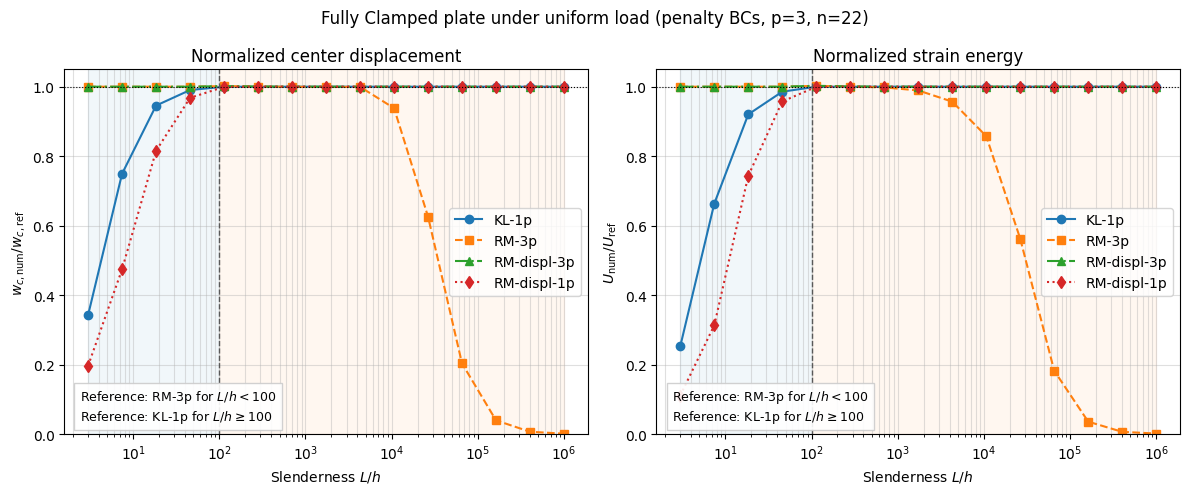

(<Figure size 1200x500 with 2 Axes>,
 (<Axes: title={'center': 'Normalized center displacement'}, xlabel='Slenderness $L/h$', ylabel='$w_{c,\\mathrm{num}} / w_{c,\\mathrm{ref}}$'>,
  <Axes: title={'center': 'Normalized strain energy'}, xlabel='Slenderness $L/h$', ylabel='$U_\\mathrm{num} / U_\\mathrm{ref}$'>))

In [12]:
results_clamped = run_case_study("clamped")
plot_case_results(results_clamped, displacement_ylim=(0.0, 1.05), energy_ylim=(0.0, 1.05))

## Simply Supported

The single-parameter Reissner-Mindlin formulation (`RM-displ-1p`) with the displacement reformulation $w = w_b + w_s$ (using a single scalar for shear transverse displacement) seems to work in this particular case due to the curl-free character of the rotation field.

This clearly tells us that, regardless of a single $w_s$ being enough for a beam description, two independent transverse shear displacements are needed for a complete enrichment of the Kirchhoff solution, as proposed by Oesterle et.al. in [3].

All other formulations return the expected results.

Simply Supported plate under uniform load
Penalty enforcement with alpha = 1.0e+06 Kb / L^3
       L/h |    Ref |       KL |      RM3 |     RMD3 |      RM1
-----------------------------------------------------------------------
      3.00 |  RM-3p |   0.6346 |   1.0000 |   1.0000 |   1.0001
      7.44 |  RM-3p |   0.9144 |   1.0000 |   1.0000 |   1.0000
     18.45 |  RM-3p |   0.9850 |   1.0000 |   1.0000 |   1.0000
     45.77 |  RM-3p |   0.9975 |   1.0000 |   1.0000 |   1.0000
    113.52 |  KL-1p |   1.0000 |   1.0004 |   1.0004 |   1.0004
    281.56 |  KL-1p |   1.0000 |   1.0001 |   1.0001 |   1.0001
    698.34 |  KL-1p |   1.0000 |   1.0001 |   1.0000 |   1.0000
   1732.05 |  KL-1p |   1.0000 |   1.0004 |   1.0000 |   1.0000
   4295.88 |  KL-1p |   1.0000 |   1.0019 |   1.0000 |   1.0000
  10654.75 |  KL-1p |   1.0000 |   0.9950 |   1.0000 |   1.0000
  26426.20 |  KL-1p |   1.0000 |   0.9538 |   1.0000 |   1.0000
  65542.95 |  KL-1p |   1.0000 |   0.8995 |   1.0000 |   1.0000
 162

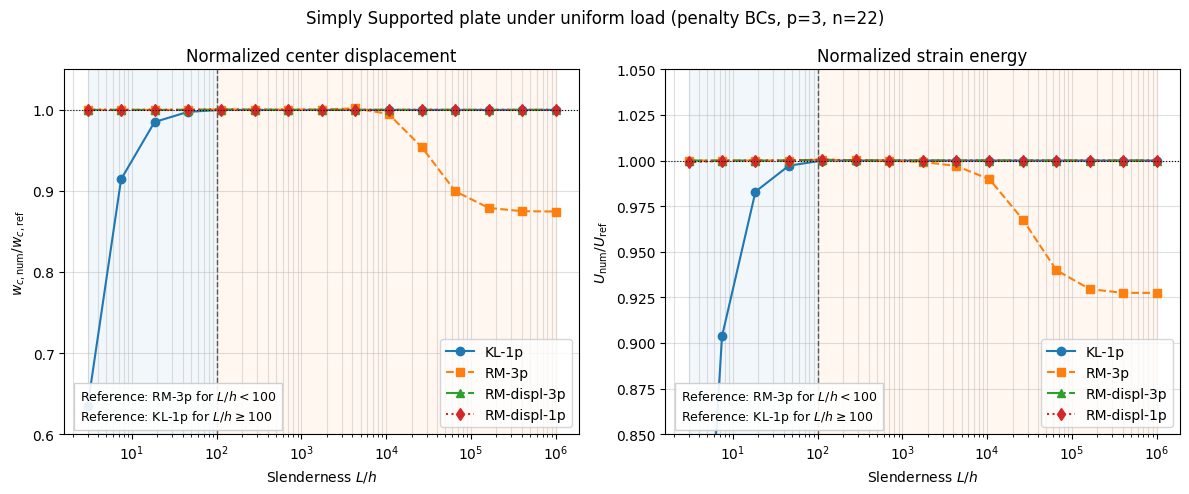

(<Figure size 1200x500 with 2 Axes>,
 (<Axes: title={'center': 'Normalized center displacement'}, xlabel='Slenderness $L/h$', ylabel='$w_{c,\\mathrm{num}} / w_{c,\\mathrm{ref}}$'>,
  <Axes: title={'center': 'Normalized strain energy'}, xlabel='Slenderness $L/h$', ylabel='$U_\\mathrm{num} / U_\\mathrm{ref}$'>))

In [13]:
results_simply_supported = run_case_study("simply_supported")
plot_case_results(results_simply_supported, displacement_ylim=(0.6, 1.05), energy_ylim=(0.85, 1.05))

## Cantilever-Type

Cantilever-Type plate under uniform load
Penalty enforcement with alpha = 1.0e+06 Kb / L^3
       L/h |    Ref |       KL |      RM3 |     RMD3 |      RM1
-----------------------------------------------------------------------
      3.00 |  RM-3p |   0.8748 |   1.0000 |   1.0000 |   0.9686
      7.44 |  RM-3p |   0.9714 |   1.0000 |   1.0000 |   0.9822
     18.45 |  RM-3p |   0.9933 |   1.0000 |   1.0000 |   0.9921
     45.77 |  RM-3p |   0.9983 |   1.0000 |   1.0000 |   0.9975
    113.52 |  KL-1p |   1.0000 |   1.0005 |   1.0005 |   1.0000
    281.56 |  KL-1p |   1.0000 |   1.0001 |   1.0001 |   1.0000
    698.34 |  KL-1p |   1.0000 |   0.9997 |   1.0000 |   1.0000
   1732.05 |  KL-1p |   1.0000 |   0.9991 |   1.0000 |   1.0000
   4295.88 |  KL-1p |   1.0000 |   0.9979 |   1.0000 |   1.0000
  10654.75 |  KL-1p |   1.0000 |   0.9956 |   1.0000 |   1.0000
  26426.20 |  KL-1p |   1.0000 |   0.9913 |   1.0000 |   1.0000
  65542.95 |  KL-1p |   1.0000 |   0.9852 |   1.0000 |   1.0000
 1625

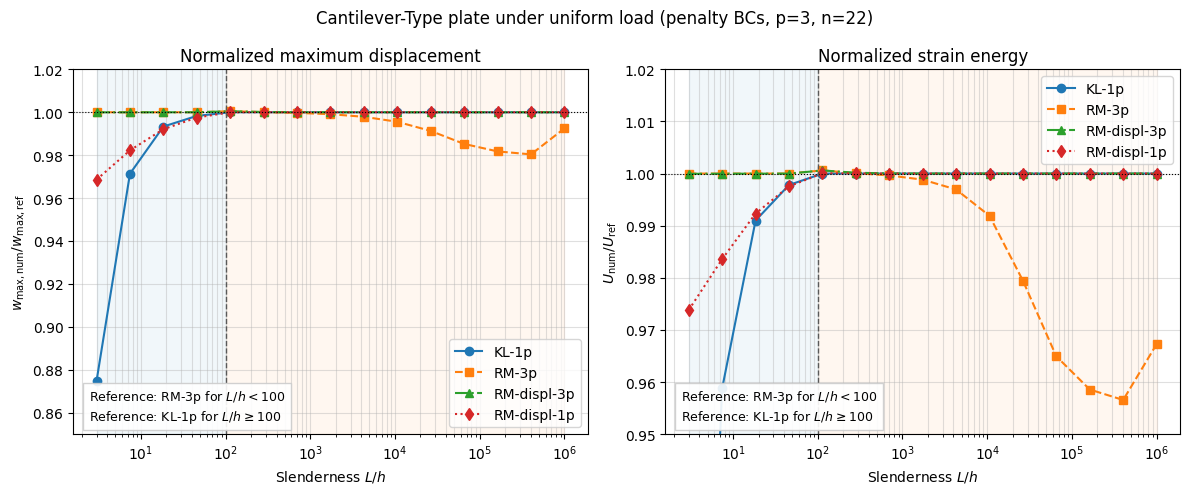

(<Figure size 1200x500 with 2 Axes>,
 (<Axes: title={'center': 'Normalized maximum displacement'}, xlabel='Slenderness $L/h$', ylabel='$w_{\\max,\\mathrm{num}} / w_{\\max,\\mathrm{ref}}$'>,
  <Axes: title={'center': 'Normalized strain energy'}, xlabel='Slenderness $L/h$', ylabel='$U_\\mathrm{num} / U_\\mathrm{ref}$'>))

In [14]:
results_cantilever = run_case_study("cantilever")
plot_case_results(results_cantilever, displacement_ylim=(0.85, 1.02), energy_ylim=(0.95, 1.02))